# LAND-AS visualization notebook

In [11]:
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np
import pandas as pd
import rasterio
import xarray as xr

warnings.filterwarnings('ignore')

PACKAGE_DIR = Path.cwd()
if not (PACKAGE_DIR / 'config.py').exists():
    if (PACKAGE_DIR / 'LAND_AS').exists():
        PACKAGE_DIR = PACKAGE_DIR / 'LAND_AS'
    elif (PACKAGE_DIR.parent / 'config.py').exists():
        PACKAGE_DIR = PACKAGE_DIR.parent
REPO_ROOT = PACKAGE_DIR.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from LAND_AS import config

plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 180, 'font.size': 9})
FIG_DIR = PACKAGE_DIR / 'output' / 'figures' / 'viz'
FIG_DIR.mkdir(parents=True, exist_ok=True)

meta = pd.read_csv(REPO_ROOT / 'raw_data' / 'AS' / 'station_locations.csv').rename(
    columns={'Station': 'station', 'LAT': 'lat', 'LONG': 'lon'})
for col in ['lat', 'lon']:
    meta[col] = pd.to_numeric(meta[col], errors='coerce')
meta['role'] = np.where(meta['station'].isin(config.TEST_STATIONS), 'test', 'train')

dataset = np.load(config.DATASET_PATH, allow_pickle=True)
stations = dataset['stations'].astype(str)
years = dataset['years'].astype(int)
dates = pd.to_datetime({'year': years, 'month': dataset['months'].astype(int),
                        'day': dataset['days'].astype(int)})
rain = dataset['rainfall_mm_raw'].astype(float)
test_mask = np.isin(stations, config.TEST_STATIONS) & (years > config.TRAIN_YEAR_END)

RAW_DIR = REPO_ROOT / 'raw_data' / 'AS' / 'final_rainfall_per_station'

def load_station_csv(path):
    df = pd.read_csv(path)
    df['date'] = pd.to_datetime(df['datetime'], format='%m/%d/%Y')
    col = [c for c in df.columns if c.startswith('precip')][0]
    scale = 25.4 if col.endswith('_in') else 1.0
    df['mm'] = pd.to_numeric(df[col], errors='coerce') * scale
    return df.set_index('date')['mm']

raw_daily = {p.stem: load_station_csv(p) for p in sorted(RAW_DIR.glob('*.csv'))}
print(f'{len(raw_daily)} raw station files; dataset has {len(rain)} weeks, {test_mask.sum()} test')


27 raw station files; dataset has 9459 weeks, 837 test


## Data coverage over time

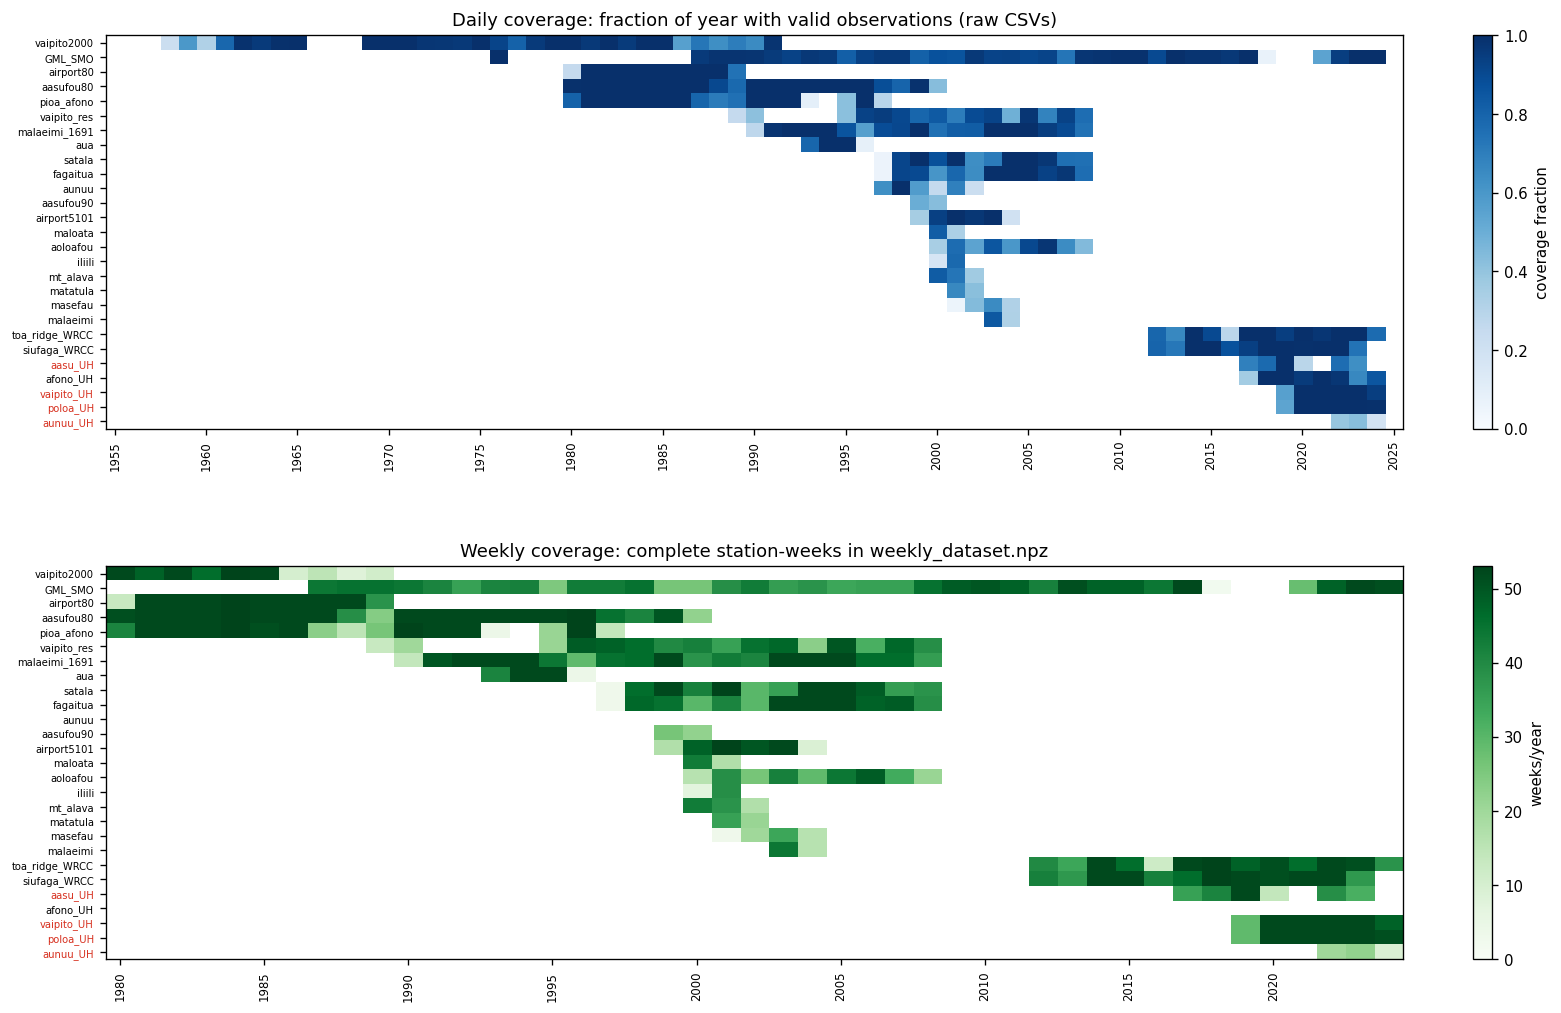

In [12]:
all_years = np.arange(1955, 2026)

# daily coverage: valid-obs fraction of each year
cov = pd.DataFrame(index=sorted(raw_daily), columns=all_years, dtype=float)
for name, s in raw_daily.items():
    valid = s.dropna()
    counts = valid.groupby(valid.index.year).size()
    for y, n in counts.items():
        cov.loc[name, y] = n / (366 if pd.Timestamp(y, 1, 1).is_leap_year else 365)

first_year = cov.apply(lambda r: r.first_valid_index(), axis=1)
cov = cov.loc[first_year.sort_values().index]

# weekly coverage: complete station-weeks per year in the npz
wk = pd.DataFrame({'station': stations, 'year': years})
wk_cov = wk.value_counts().unstack('station').T.reindex(cov.index)

fig, axes = plt.subplots(2, 1, figsize=(15, 10), gridspec_kw={'hspace': 0.35})

im0 = axes[0].imshow(np.ma.masked_invalid(cov.values.astype(float)), aspect='auto',
                     cmap='Blues', vmin=0, vmax=1)
axes[0].set_yticks(range(len(cov))); axes[0].set_yticklabels(cov.index, fontsize=6)
axes[0].set_xticks(np.arange(0, len(all_years), 5))
axes[0].set_xticklabels(all_years[::5], rotation=90, fontsize=7)
axes[0].set_title('Daily coverage: fraction of year with valid observations (raw CSVs)')
plt.colorbar(im0, ax=axes[0], label='coverage fraction', fraction=0.02)

im1 = axes[1].imshow(np.ma.masked_invalid(wk_cov.values.astype(float)), aspect='auto',
                     cmap='Greens', vmin=0, vmax=53)
axes[1].set_yticks(range(len(wk_cov))); axes[1].set_yticklabels(wk_cov.index, fontsize=6)
axes[1].set_xticks(np.arange(0, wk_cov.shape[1], 5))
axes[1].set_xticklabels(wk_cov.columns[::5], rotation=90, fontsize=7)
axes[1].set_title('Weekly coverage: complete station-weeks in weekly_dataset.npz')
plt.colorbar(im1, ax=axes[1], label='weeks/year', fraction=0.02)

for ax in axes:
    for j, s in enumerate(cov.index):
        if s in config.TEST_STATIONS:
            ax.get_yticklabels()[j].set_color('#d7301f')
fig.savefig(FIG_DIR / 'data_coverage.svg', bbox_inches='tight')
plt.show()


## Zero rates per station (from source)

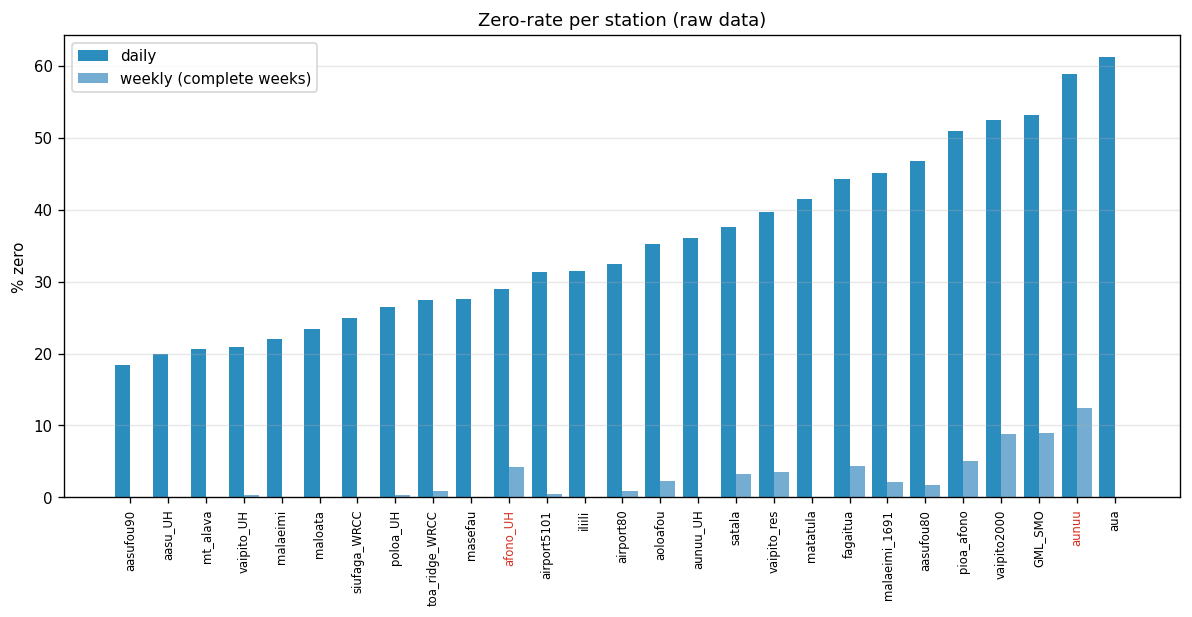

                daily_zero_%  weekly_zero_%  n_days
station                                            
aasufou90              18.48           0.00     341
aasu_UH                20.00           0.00    1515
mt_alava               20.60           0.00     704
vaipito_UH             20.95           0.35    2010
malaeimi               22.07           0.00     426
maloata                23.40           0.00     423
siufaga_WRCC           24.98           0.00    4043
poloa_UH               26.50           0.35    2023
toa_ridge_WRCC         27.45           0.87    4135
masefau                27.53           0.00     534
afono_UH               29.00           4.27    2486
airport5101            31.30           0.44    1626
iliili                 31.50           0.00     346
airport80              32.50           0.85    3286
aoloafou               35.29           2.34    2219
aunuu_UH               36.07           0.00     366
satala                 37.52           3.28    3534
vaipito_res 

In [13]:
zero_rows = []
for name, s in raw_daily.items():
    valid = s.dropna()
    daily_zero = float((valid == 0).mean())
    week = valid.resample('W-SUN').agg(['count', 'sum'])
    complete = week[week['count'] == 7]
    weekly_zero = float((complete['sum'] == 0).mean()) if len(complete) else np.nan
    zero_rows.append({'station': name, 'daily_zero_%': 100 * daily_zero,
                      'weekly_zero_%': 100 * weekly_zero,
                      'n_days': len(valid)})
zero_df = pd.DataFrame(zero_rows).set_index('station').sort_values('daily_zero_%')

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(zero_df))
ax.bar(x - 0.2, zero_df['daily_zero_%'], width=0.4, label='daily', color='#2b8cbe')
ax.bar(x + 0.2, zero_df['weekly_zero_%'], width=0.4, label='weekly (complete weeks)', color='#74add1')
ax.set_xticks(x); ax.set_xticklabels(zero_df.index, rotation=90, fontsize=7)
for j, s in enumerate(zero_df.index):
    if s in {'aunuu', 'afono_UH'}:
        ax.get_xticklabels()[j].set_color('#d7301f')
ax.set_ylabel('% zero'); ax.set_title('Zero-rate per station (raw data)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
fig.savefig(FIG_DIR / 'zero_rates.svg', bbox_inches='tight')
plt.show()
print(zero_df.round(2).to_string())


## Station map

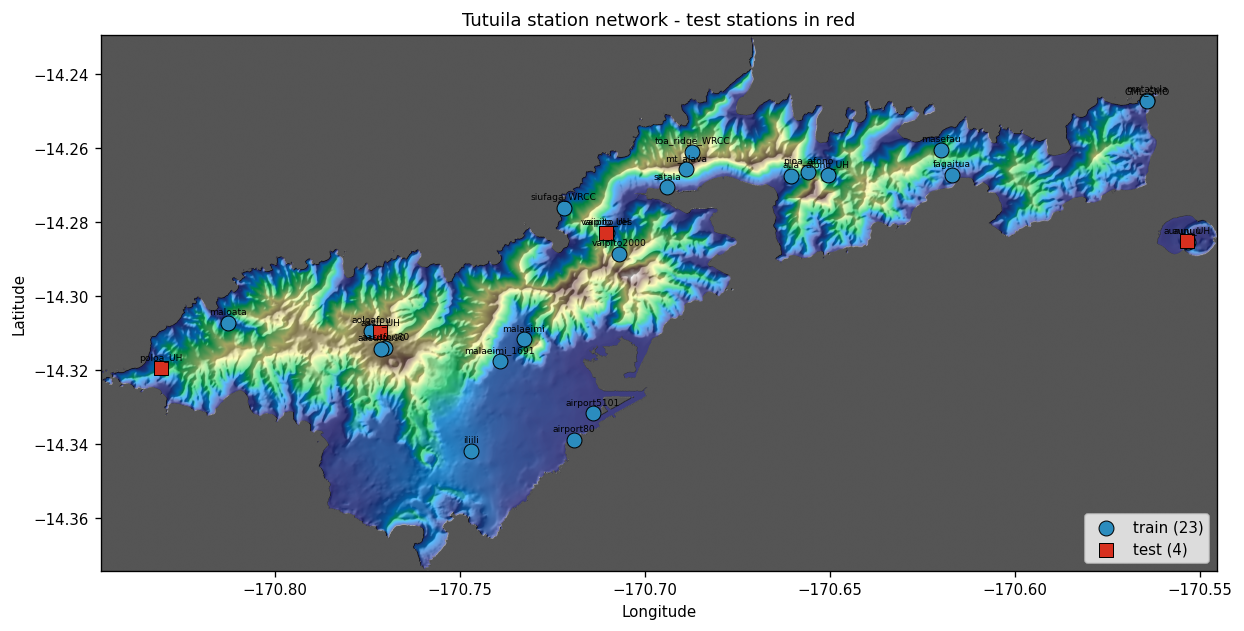

In [14]:
dem_path = REPO_ROOT / 'raw_data' / 'AS' / 'DEM' / '10m_tutuila_3band.tif'
with rasterio.open(dem_path) as src:
    bounds = src.bounds
    nodata = src.nodata
    elev_full = src.read(1).astype(float)
elev_full = np.where(elev_full == nodata, np.nan, elev_full)
step = max(1, elev_full.shape[0] // 1200)
elev = elev_full[::step, ::step]
extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

# hillshade from gradients of the (smoothly downsampled) DEM
gy, gx = np.gradient(np.nan_to_num(elev, nan=0.0))
shade = np.clip(0.7 + 0.3 * (-gx * 0.8 - gy * 0.6), 0.4, 1.3)

fig, ax = plt.subplots(figsize=(12, 6.5))
land = np.ma.masked_invalid(np.where(elev <= 0, np.nan, elev))
ax.imshow(shade, extent=extent, cmap='gray', vmin=0.4, vmax=1.3)
ax.imshow(land, extent=extent, cmap='terrain', vmin=0, alpha=0.65)
for role, color, marker in [('train', '#2b8cbe', 'o'), ('test', '#d7301f', 's')]:
    sub = meta[meta['role'] == role]
    ax.scatter(sub['lon'], sub['lat'], color=color, marker=marker, s=80,
               edgecolor='k', linewidth=0.6, label=f'{role} ({len(sub)})', zorder=5)
for _, row in meta.iterrows():
    ax.annotate(row['station'], (row['lon'], row['lat']), fontsize=5.5,
                xytext=(0, 5), textcoords='offset points', ha='center', zorder=6)
ax.set_xlim(bounds.left, bounds.right); ax.set_ylim(bounds.bottom, bounds.top)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('Tutuila station network - test stations in red')
ax.legend(loc='lower right')
fig.savefig(FIG_DIR / 'station_map.svg', bbox_inches='tight')
plt.show()


## Input features as pixel grids

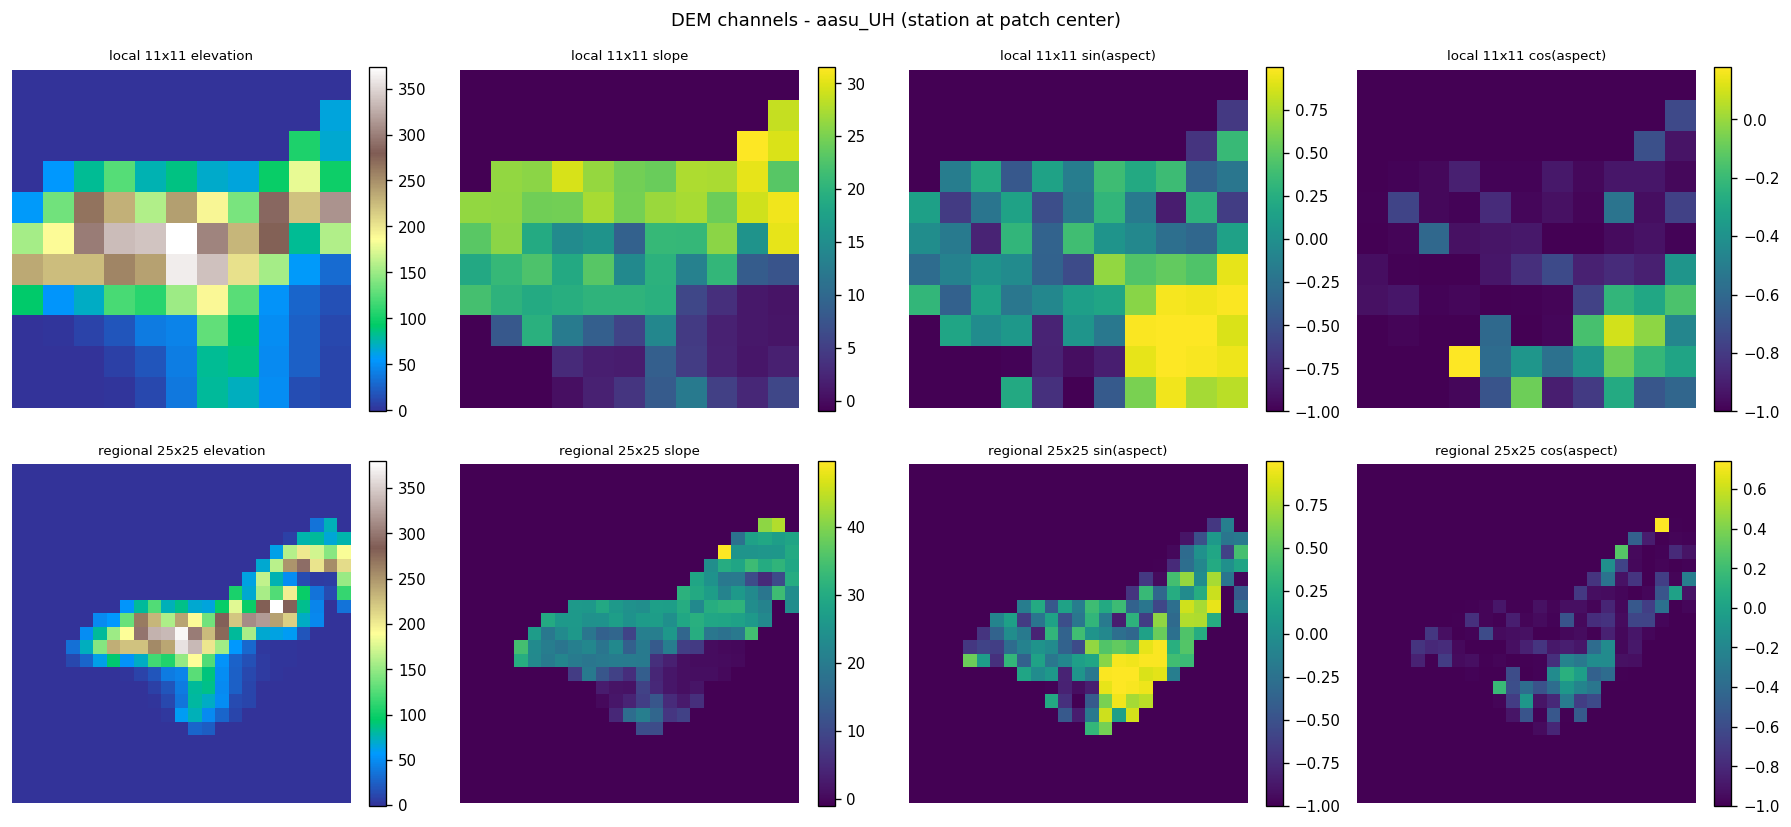

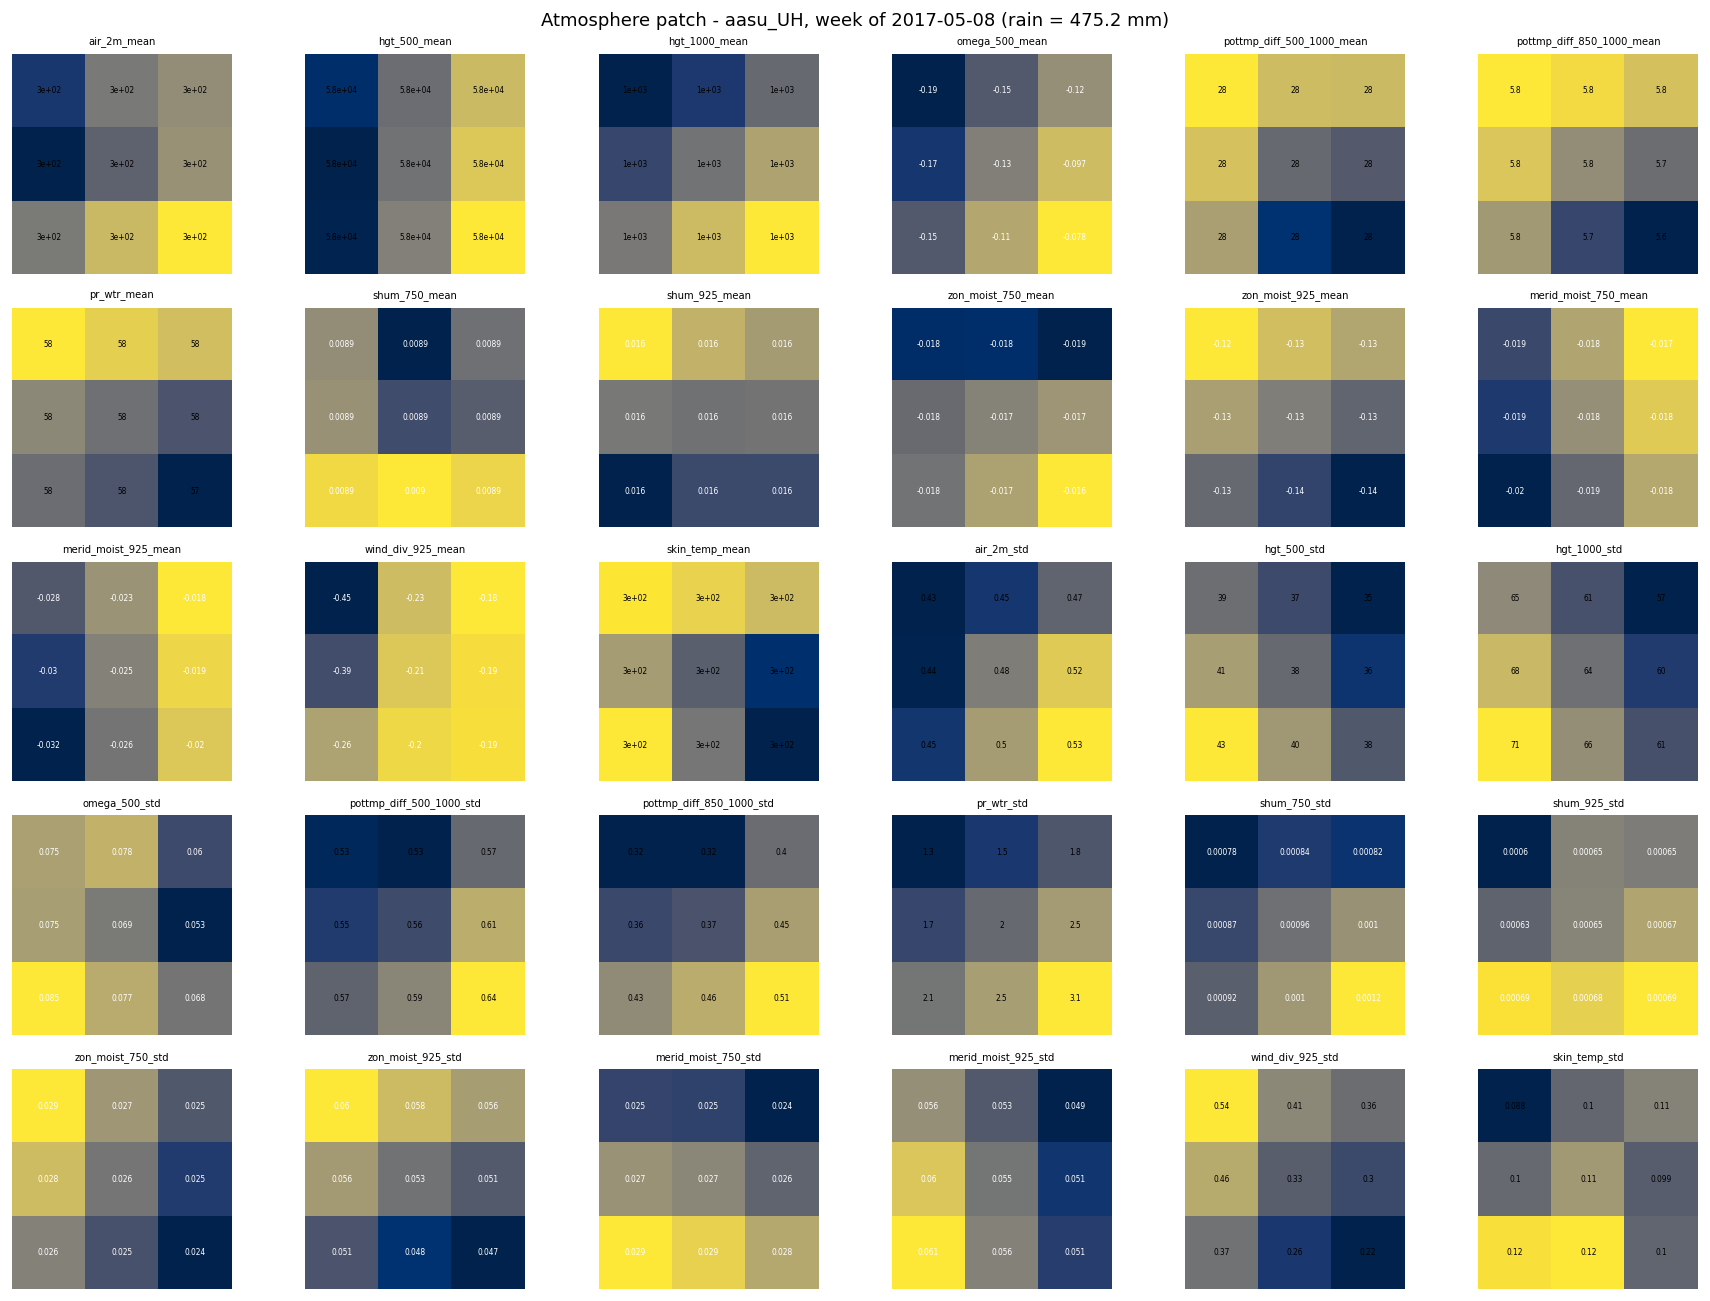

In [15]:
# pick the wettest test week at a test station for a vivid example
test_idx = np.where(test_mask)[0]
example = int(test_idx[np.argmax(rain[test_idx])])
ex_station = stations[example]
dem_stations = dataset['dem_stations'].astype(str)
dem_idx = int(np.where(dem_stations == ex_station)[0])

bands = ['elevation', 'slope', 'sin(aspect)', 'cos(aspect)']
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for b, name in enumerate(bands):
    for r, (arr, tag) in enumerate([(dataset['dem_local_raw'][dem_idx], 'local 11x11'),
                                  (dataset['dem_regional_raw'][dem_idx], 'regional 25x25')]):
        im = axes[r, b].imshow(arr[b], cmap='terrain' if b == 0 else 'viridis')
        axes[r, b].set_title(f'{tag} {name}', fontsize=8)
        axes[r, b].axis('off')
        plt.colorbar(im, ax=axes[r, b], fraction=0.046)
fig.suptitle(f'DEM channels - {ex_station} (station at patch center)')
plt.tight_layout()
fig.savefig(FIG_DIR / 'dem_channels.svg', bbox_inches='tight')
plt.show()

var_names = dataset['variables'].astype(str)
patch = dataset['reanalysis_patches'][example]  # (30, 3, 3)
fig, axes = plt.subplots(5, 6, figsize=(15, 11))
for c in range(30):
    ax = axes.ravel()[c]
    im = ax.imshow(patch[c], cmap='cividis')
    ax.set_title(var_names[c], fontsize=6)
    ax.axis('off')
    for i in range(3):
        for j in range(3):
            v = patch[c, i, j]
            ax.text(j, i, f'{v:.2g}', ha='center', va='center', fontsize=4.5,
                    color='w' if v < np.nanmedian(patch) else 'k')
fig.suptitle(f'Atmosphere patch - {ex_station}, week of {dates[example]:%Y-%m-%d} '
             f'(rain = {rain[example]:.1f} mm)')
plt.tight_layout()
fig.savefig(FIG_DIR / 'climate_patch.svg', bbox_inches='tight')
plt.show()


## What is inside `weekly_dataset.npz`

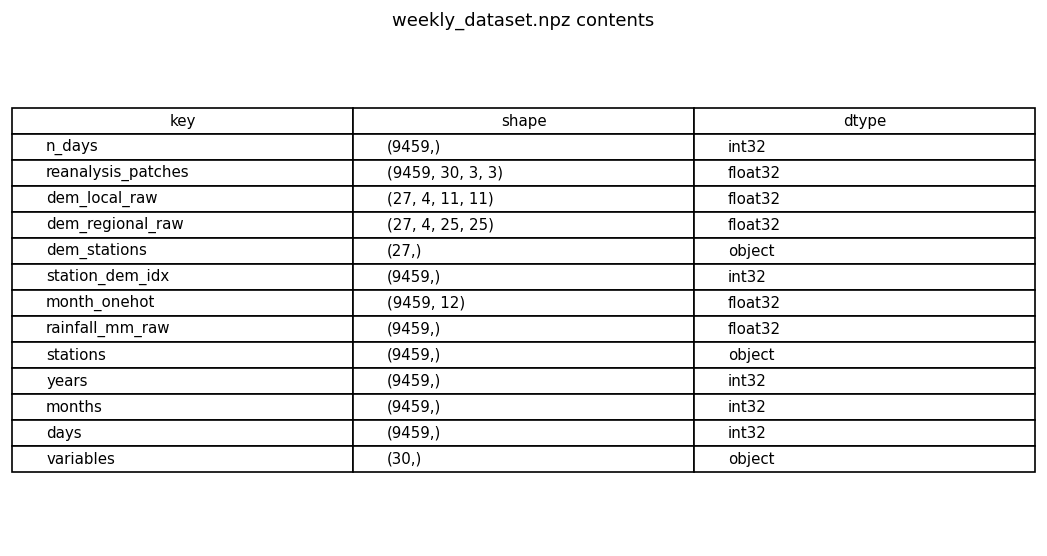

Example sample index 1464
  stations        = aasu_UH
  year/month/day  = 2017/5/8  (week starting 2017-05-08)
  n_days          = 7
  rainfall_mm_raw = 475.23 mm
  month_onehot    = [0 0 0 0 1 0 0 0 0 0 0 0]  (May)

reanalysis_patches[1464] shape (30, 3, 3)  (channel, row N->S, col W->E)
  [ 0] air_2m_mean:
[[300.181 300.237 300.253]
 [300.162 300.218 300.256]
 [300.237 300.285 300.314]]
  [ 1] hgt_500_mean:
[[57668.008 57670.770 57673.680]
 [57667.488 57670.938 57674.160]
 [57667.520 57671.512 57675.125]]
  [ 2] hgt_1000_mean:
[[1023.500 1026.324 1032.011]
 [1027.956 1033.192 1038.415]
 [1033.837 1040.881 1044.810]]
  [ 3] omega_500_mean:
[[-0.186 -0.151 -0.121]
 [-0.173 -0.129 -0.097]
 [-0.152 -0.108 -0.078]]
  [ 4] pottmp_diff_500_1000_mean:
[[27.909 27.890 27.889]
 [27.893 27.848 27.839]
 [27.877 27.815 27.806]]
  [ 5] pottmp_diff_850_1000_mean:
[[5.844 5.834 5.811]
 [5.816 5.759 5.724]
 [5.771 5.678 5.635]]
  [ 6] pr_wtr_mean:
[[58.173 58.091 58.030]
 [57.809 57.703 57.568]
 [57.

In [16]:
rows = []
for k in dataset.files:
    a = dataset[k]
    rows.append([k, str(a.shape), str(a.dtype)])

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.axis('off')
tbl = ax.table(cellText=rows, colLabels=['key', 'shape', 'dtype'],
               loc='center', cellLoc='left')
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 1.3)
ax.set_title('weekly_dataset.npz contents')
fig.savefig(FIG_DIR / 'npz_contents.svg', bbox_inches='tight')
plt.show()

# ---- Full dump of every array for one example week ----
np.set_printoptions(linewidth=230, precision=3, suppress=True,
                    threshold=np.inf, floatmode='maxprec_equal')
var_names = dataset['variables'].astype(str)
dem_bands = ['elevation_m', 'slope_deg', 'sin_aspect', 'cos_aspect']

i = example
print(f'Example sample index {i}')
print(f'  stations        = {stations[i]}')
print(f'  year/month/day  = {int(years[i])}/{int(dataset["months"][i])}/{int(dataset["days"][i])}'
      f'  (week starting {dates[i]:%Y-%m-%d})')
print(f'  n_days          = {int(dataset["n_days"][i])}')
print(f'  rainfall_mm_raw = {rain[i]:.2f} mm')
print(f'  month_onehot    = {dataset["month_onehot"][i].astype(int)}'
      f'  ({dates[i]:%B})')

print(f'\nreanalysis_patches[{i}] shape {dataset["reanalysis_patches"][i].shape}'
      '  (channel, row N->S, col W->E)')
for c, name in enumerate(var_names):
    print(f'  [{c:2d}] {name}:')
    print(dataset['reanalysis_patches'][i, c])

di = int(dataset['station_dem_idx'][i])
print(f'\nstation_dem_idx = {di} -> {dem_stations[di]}'
      '  (per-station index into the DEM arrays below; ocean cells = -1)')
for key, tag in [('dem_local_raw', '11x11 cells @ 1 km -> 11 km box'),
                 ('dem_regional_raw', '25x25 cells @ 1 km -> 25 km box')]:
    arr = dataset[key][di]
    print(f'\n{key}[{di}] shape {arr.shape}  -- {tag}')
    for b, band in enumerate(dem_bands):
        print(f'  [{b}] {band}:')
        print(arr[b])


## Reanalysis channel correlation (raw values)

16422 unique days x 15 channels (1980-01-01 .. 2024-12-31)


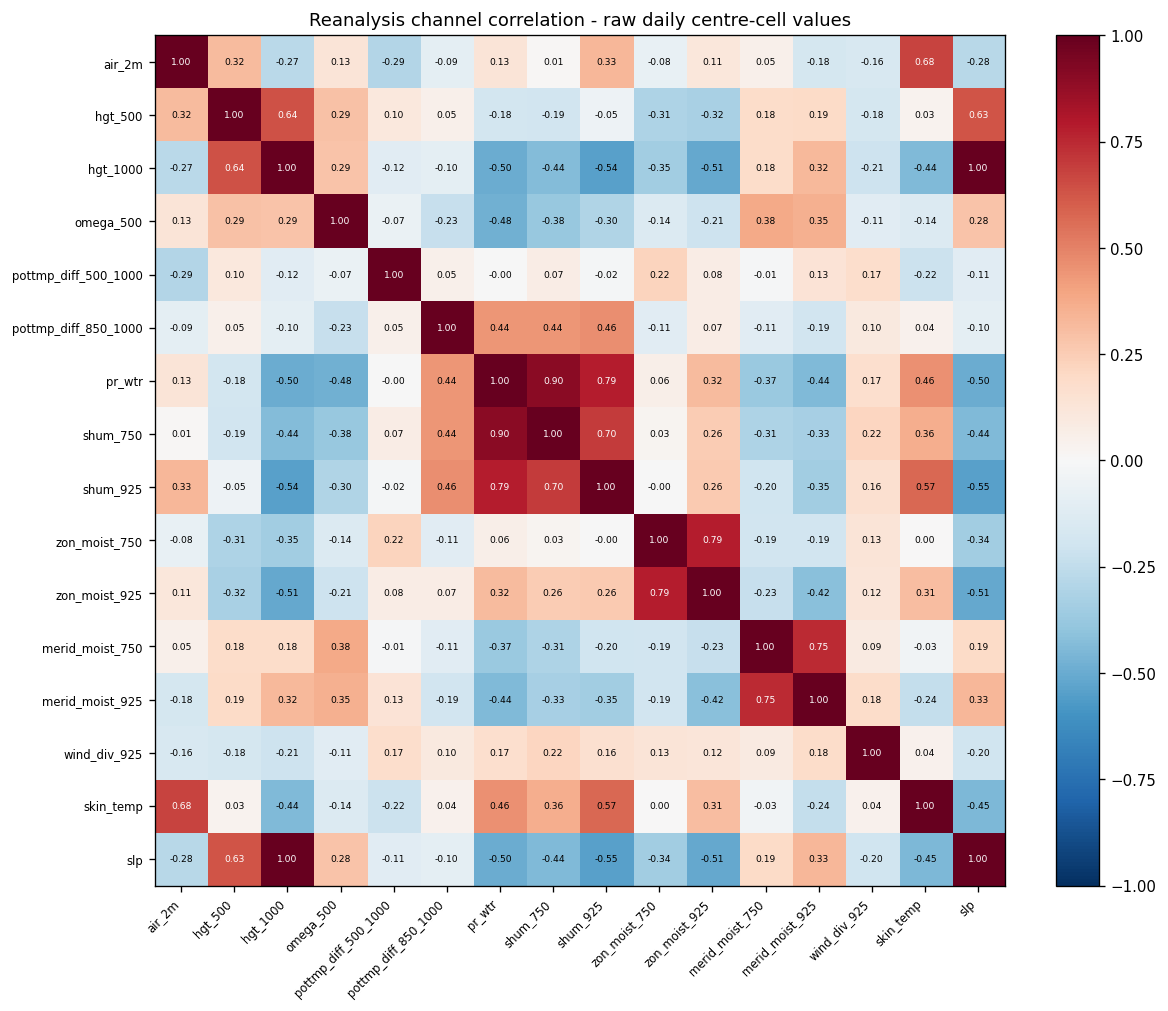

Strongest |r| pairs:
  hgt_1000                 x slp                       r = +1.000
  pr_wtr                   x shum_750                  r = +0.905
  pr_wtr                   x shum_925                  r = +0.789
  zon_moist_750            x zon_moist_925             r = +0.787
  merid_moist_750          x merid_moist_925           r = +0.747
  shum_750                 x shum_925                  r = +0.697
  air_2m                   x skin_temp                 r = +0.675
  hgt_500                  x hgt_1000                  r = +0.637

slp x hgt_1000 r = +0.9999 -> slp dropped


In [17]:
feat = np.load(PACKAGE_DIR / 'data' / 'features' / 'reanalysis_daily.npz',
               allow_pickle=True)
ch_names = feat['variables'].astype(str)
fdate = pd.to_datetime({'year': feat['years'], 'month': feat['months'],
                        'day': feat['days']})
centre = pd.DataFrame(feat['patches'][:, :, 1, 1], columns=ch_names)
centre['date'] = fdate.values
daily = centre.groupby('date').mean().sort_index()
print(f'{daily.shape[0]} unique days x {daily.shape[1]} channels '
      f'({daily.index[0]:%Y-%m-%d} .. {daily.index[-1]:%Y-%m-%d})')

# slp raw daily value at the grid point nearest the island centre
CLIM_DIR = REPO_ROOT / 'raw_data' / 'AS' / 'climate_variables_daily_1980-2024'
slp_ds = xr.open_dataset(CLIM_DIR / 'slp.day.mean.nc')
lat_n = 'latitude' if 'latitude' in slp_ds.dims else 'lat'
lon_n = 'longitude' if 'longitude' in slp_ds.dims else 'lon'
t_n = 'valid_time' if 'valid_time' in slp_ds.dims else 'time'
slp_var = list(slp_ds.data_vars)[0]
pt = slp_ds[slp_var].sel({lat_n: float(meta['lat'].mean()),
                          lon_n: float(meta['lon'].mean())}, method='nearest')
slp_ts = pd.Series(np.asarray(pt.values).ravel(),
                   index=pd.DatetimeIndex(slp_ds[t_n].values))
daily['slp'] = slp_ts.reindex(daily.index)
slp_ds.close()

corr = daily.corr()
fig, ax = plt.subplots(figsize=(10, 8.5))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=7)
ax.set_yticklabels(corr.columns, fontsize=7)
for r_ in range(len(corr)):
    for c_ in range(len(corr)):
        v = corr.values[r_, c_]
        ax.text(c_, r_, f'{v:.2f}' if np.isfinite(v) else 'nan',
                ha='center', va='center', fontsize=5.5,
                color='w' if abs(v) > 0.6 else 'k')
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title('Reanalysis channel correlation - raw daily centre-cell values')
plt.tight_layout()
fig.savefig(FIG_DIR / 'reanalysis_correlation.svg', bbox_inches='tight')
plt.show()

pairs = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
         .stack().sort_values(key=abs, ascending=False))
print('Strongest |r| pairs:')
for (a, b), v in pairs.head(8).items():
    print(f'  {a:24s} x {b:24s}  r = {v:+.3f}')
print(f"\nslp x hgt_1000 r = {corr.loc['slp', 'hgt_1000']:+.4f} -> slp dropped")


## Baseline metrics on the test set

                                      rmse        mae       bias        r2  spearman   p98_bias     csi50
gbm                               49.17497  33.180743 -12.226422  0.462324  0.707494 -26.559517  0.637363
ols                              49.378631  36.377888   0.794479  0.457861  0.680254 -24.567213   0.64366
weekly_land_v3_huber_recent_bal  49.478753  35.871345   2.698145  0.455661  0.685448 -26.516385  0.638935
tweedie_glm                      59.391438  37.165777 -15.400221  0.215704  0.701484 -22.811228  0.616858
month_climatology                66.461124  48.653154  -6.019194  0.017873  0.182322 -66.393677  0.537634
pooled_mean                      67.341174  49.816132  -6.113055 -0.008309       NaN -73.457826  0.537634
persistence                       88.37931  64.313088  -0.131982 -0.736735  0.121509  -0.648577  0.395994


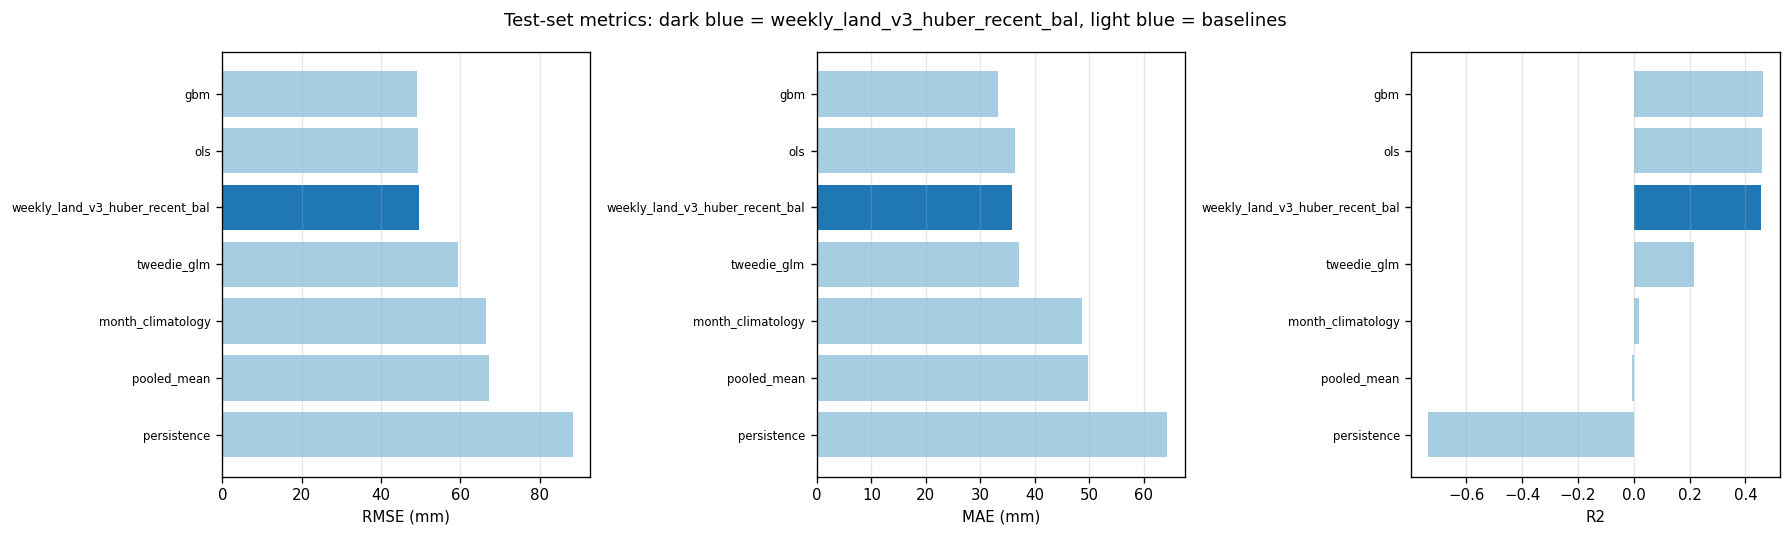

In [18]:
# only the selected LAND run, not every run in output/runs
run = 'weekly_land_v3_huber_recent_bal'
base_metrics = json.loads((PACKAGE_DIR / 'output' / 'baselines' / 'test_metrics.json').read_text())
model_metrics = json.loads((PACKAGE_DIR / 'output' / 'baselines' / 'model_metrics.json').read_text())
all_metrics = {run: model_metrics[run], **base_metrics}
mdf = (pd.DataFrame(all_metrics).T
       [['rmse', 'mae', 'bias', 'r2', 'spearman_r', 'pctl_rel_bias', 'csi_50mm']]
       .rename(columns={'spearman_r': 'spearman', 'pctl_rel_bias': 'p98_bias',
                        'csi_50mm': 'csi50'}))
mdf['p98_bias'] *= 100
mdf = mdf.sort_values('rmse')
print(mdf.round(3).to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
colors = ['#1f78b4' if n == run else '#a6cee3' for n in mdf.index]
for ax, metric, label in [(axes[0], 'rmse', 'RMSE (mm)'), (axes[1], 'mae', 'MAE (mm)'),
                          (axes[2], 'r2', 'R2')]:
    ax.barh(range(len(mdf)), mdf[metric], color=colors)
    ax.set_yticks(range(len(mdf)))
    ax.set_yticklabels(mdf.index, fontsize=7)
    ax.invert_yaxis()
    ax.set_xlabel(label); ax.grid(axis='x', alpha=0.3)
fig.suptitle(f'Test-set metrics: dark blue = {run}, light blue = baselines')
plt.tight_layout()
fig.savefig(FIG_DIR / 'baseline_metrics.svg', bbox_inches='tight')
plt.show()


## Architecture - `weekly_land_v3_huber_recent_bal`

hyperparameters: {"climate_units": 390, "dem_units": 32, "month_units": 16, "hidden_units": 320, "dropout": 0.6323276455457959, "dem_size": 8, "climate_lag_weeks": 0, "rain_lag_weeks": 0, "batch_size": 2048, "learning_rate": 0.0009133995846860973, "weight_decay": 0.0003503398491158688, "local_dem_cfg": 0, "regional_dem_cfg": 8, "lightweight": 0, "use_lag": 1, "dem_elev_only": 1, "monitor": "mse", "opt_metric": "mse_ratio", "min_epochs": 30, "model_type": "huber", "rainfall_weight": false, "balanced_stations": true, "cv_mode": "temporal", "fold_agg": "median", "search_space": "broad", "dataset_freq": "weekly", "loss_type": "huber_weighted", "huber_delta": 0.5, "train_cv_mode": "loso_recent"}
metadata: {'climate_shape': (30, 3, 3), 'dem_channels': 4, 'lag_dim': 0} | params: 439255


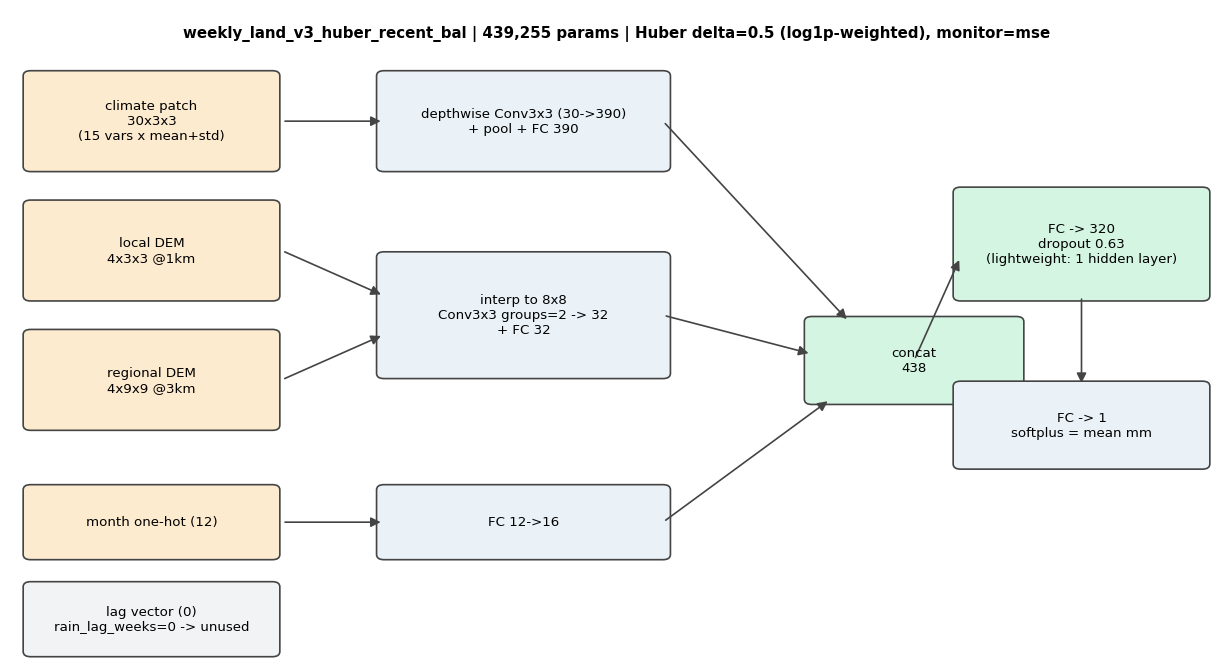

In [19]:
from LAND_AS.s2_dataset.data import (load_data, model_metadata, crop_from_hp,
                                    DEM_LOCAL_CHOICES, DEM_REGIONAL_CHOICES)
from LAND_AS.s3_model.model import build_model

run = 'weekly_land_v3_huber_recent_bal'
hp = json.loads((PACKAGE_DIR / 'output' / 'runs' / run / 'hyperparameters.json').read_text())
bundle = load_data(freq='weekly')
mdl_meta = model_metadata(bundle, hp.get('climate_patch'), hp.get('climate_lag_weeks'),
                          hp.get('rain_lag_weeks'), dem_channels=hp.get('dem_channels'))
model = build_model(hp, mdl_meta)
n_params = sum(p.numel() for p in model.parameters())
print('hyperparameters:', json.dumps(hp, default=str)[:900])
print('metadata:', mdl_meta, '| params:', n_params)

loc = DEM_LOCAL_CHOICES[hp['local_dem_cfg']]
reg = DEM_REGIONAL_CHOICES[hp['regional_dem_cfg']]
C, H, W = mdl_meta['climate_shape']
dem_ch = mdl_meta['dem_channels']

fig, ax = plt.subplots(figsize=(13, 7))
ax.set_xlim(0, 13); ax.set_ylim(0, 10); ax.axis('off')

def box(x, y, w, h, text, fc='#eaf2f8', fs=8):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.08',
                                fc=fc, ec='#444', lw=1))
    ax.text(x + w / 2, y + h / 2, text, ha='center', va='center', fontsize=fs)

def arrow(x1, y1, x2, y2):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle='-|>',
                                 mutation_scale=12, color='#444', lw=1))

box(0.2, 7.6, 2.6, 1.4, f'climate patch\n{C}x{H}x{W}\n(15 vars x mean+std)', '#fdebd0')
box(0.2, 5.6, 2.6, 1.4, f'local DEM\n{dem_ch}x{loc[0]}x{loc[0]} @{loc[1]}km', '#fdebd0')
box(0.2, 3.6, 2.6, 1.4, f'regional DEM\n{dem_ch}x{reg[0]}x{reg[0]} @{reg[1]}km', '#fdebd0')
box(0.2, 1.6, 2.6, 1.0, 'month one-hot (12)', '#fdebd0')
box(0.2, 0.1, 2.6, 1.0, f'lag vector ({mdl_meta["lag_dim"]})\nrain_lag_weeks=0 -> unused', '#f2f3f4')

box(4.0, 7.6, 3.0, 1.4,
    f'depthwise Conv3x3 ({C}->{hp["climate_units"]})\n+ pool + FC {hp["climate_units"]}')
box(4.0, 4.4, 3.0, 1.8,
    f'interp to {hp["dem_size"]}x{hp["dem_size"]}\nConv3x3 groups=2 -> {hp["dem_units"]}\n+ FC {hp["dem_units"]}')
box(4.0, 1.6, 3.0, 1.0, f'FC 12->{hp["month_units"]}')

arrow(2.9, 8.3, 4.0, 8.3)
arrow(2.9, 6.3, 4.0, 5.6)
arrow(2.9, 4.3, 4.0, 5.0)
arrow(2.9, 2.1, 4.0, 2.1)

fusion = hp["climate_units"] + hp["dem_units"] + hp["month_units"] + mdl_meta['lag_dim']
box(8.6, 4.0, 2.2, 1.2, f'concat\n{fusion}', '#d5f5e3')
arrow(7.0, 8.3, 9.0, 5.2); arrow(7.0, 5.3, 8.6, 4.7); arrow(7.0, 2.1, 8.8, 4.0)

box(10.2, 5.6, 2.6, 1.6, f'FC -> {hp["hidden_units"]}\ndropout {hp["dropout"]:.2f}\n(lightweight: 1 hidden layer)', '#d5f5e3')
box(10.2, 3.0, 2.6, 1.2, 'FC -> 1\nsoftplus = mean mm')
arrow(9.7, 4.6, 10.2, 6.2); arrow(11.5, 5.6, 11.5, 4.2)

ax.text(6.5, 9.6, f'{run} | {n_params:,} params | Huber delta={hp.get("huber_delta", 0.5)} '
        f'(log1p-weighted), monitor={hp.get("monitor", "?")}',
        ha='center', fontsize=9, weight='bold')
fig.savefig(FIG_DIR / 'architecture.svg', bbox_inches='tight')
plt.show()


## Test-set predictions: LAND vs baselines

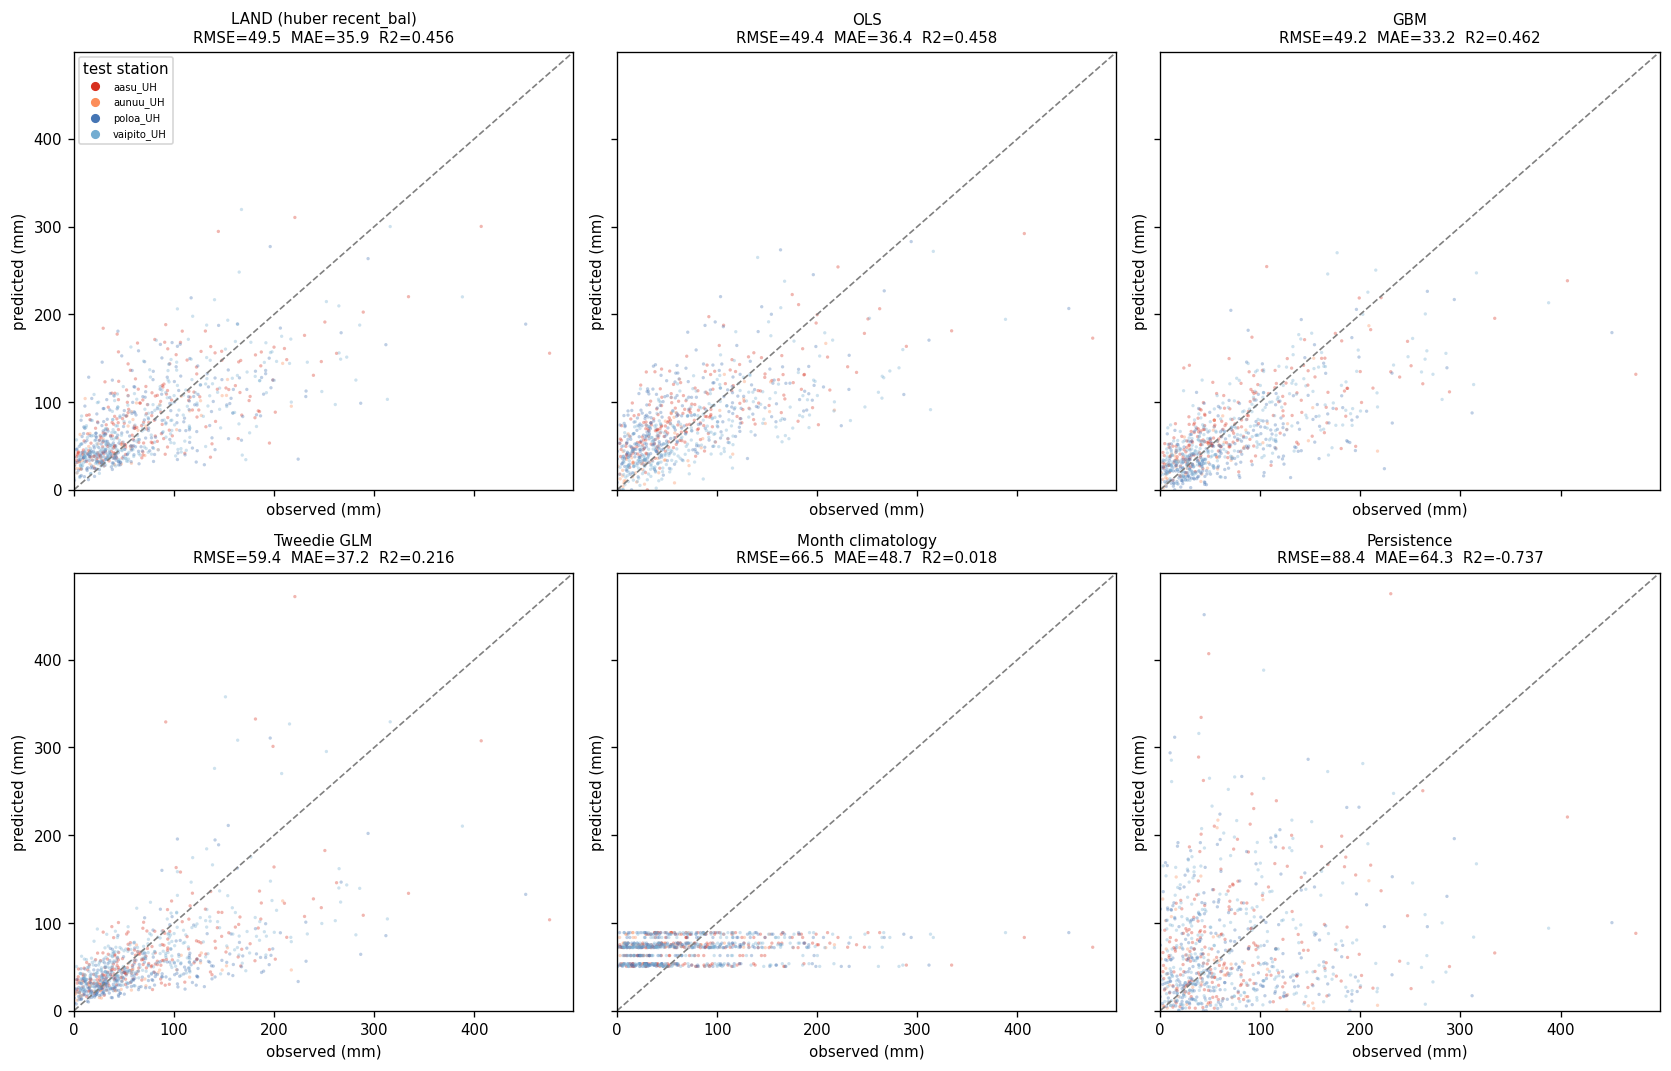

In [20]:
run_eval = np.load(PACKAGE_DIR / 'output' / 'runs' / run / 'evaluation' / 'test_predictions.npz',
                   allow_pickle=True)
base_pred = np.load(PACKAGE_DIR / 'output' / 'baselines' / 'test_predictions.npz', allow_pickle=True)

obs = run_eval['observed']
panels = [
    ('LAND (huber recent_bal)', run_eval['predicted']),
    ('OLS', base_pred['pred_ols']),
    ('GBM', base_pred['pred_gbm']),
    ('Tweedie GLM', base_pred['pred_tweedie_glm']),
    ('Month climatology', base_pred['pred_month_climatology']),
    ('Persistence', base_pred['pred_persistence']),
]
st_names = run_eval['stations'].astype(str)
st_colors = {s: c for s, c in zip(sorted(set(st_names)),
                                ['#d7301f', '#fc8d59', '#4575b4', '#74add1'])}
colors_pts = np.array([st_colors[s] for s in st_names])

fig, axes = plt.subplots(2, 3, figsize=(14, 9), sharex=True, sharey=True)
for ax, (name, pred) in zip(axes.ravel(), panels):
    ax.scatter(obs, pred, s=4, c=colors_pts, alpha=0.35, linewidths=0)
    lim = max(obs.max(), pred.max()) * 1.05
    ax.plot([0, lim], [0, lim], color='grey', lw=1, ls='--')
    r2 = 1 - np.sum((obs - pred) ** 2) / np.sum((obs - obs.mean()) ** 2)
    rmse = float(np.sqrt(np.mean((obs - pred) ** 2)))
    mae = float(np.mean(np.abs(obs - pred)))
    ax.set_title(f'{name}\nRMSE={rmse:.1f}  MAE={mae:.1f}  R2={r2:.3f}', fontsize=9)
    ax.set_xlabel('observed (mm)'); ax.set_ylabel('predicted (mm)')
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
for s, c in st_colors.items():
    axes[0, 0].scatter([], [], c=c, s=20, label=s)
axes[0, 0].legend(fontsize=6, loc='upper left', title='test station')
plt.tight_layout()
fig.savefig(FIG_DIR / 'test_scatter.svg', bbox_inches='tight')
plt.show()
